In [90]:
from torch import tensor
from torchvision import datasets, transforms
import numpy as np
import sklearn
from sklearn.model_selection import StratifiedKFold
import logging
import math
import random
from sklearn.mixture import GaussianMixture
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import kstest, anderson_ksamp, cumfreq, ks_2samp, cramervonmises, chisquare, entropy, wasserstein_distance
# from statsmodels.distributions.empirical_distribution import ECDF

In [6]:
from torchvision import datasets
from keras.preprocessing.image import ImageDataGenerator

In [119]:
def get_data(dataset_type, path=None):
    
    if dataset_type == "MNIST":
        train: datasets = datasets.MNIST(root=path, train=True, download=True, transform=None)
        test: datasets = datasets.MNIST(root=path, train=False, download=True, transform=None)
    elif dataset_type == "CIFAR10":
        transform = transforms.Compose([
            transforms.ToTensor(),
        ])
        train = datasets.CIFAR10(root=path, train=True, download=False)
        train.transform = transform
        train.data = tensor(train.data)
        train.targets = tensor(train.targets)
        test = datasets.CIFAR10(root=path, train=False, download=False)
        test.transform = transform
        test.data = tensor(test.data)
        test.targets = tensor(test.targets)

    x_train, y_train = train.data, train.targets
    x_test, y_test = test.data, test.targets

    return train, test

In [115]:
def log_class_counts(y_train, subset_ID_map, log=False):
    cls_counts = {}

    for subset_i, ID in subset_ID_map.items():
        unq, unq_cnt = np.unique(y_train[ID], return_counts=True)
        tmp = {unq[i]: unq_cnt[i] for i in range(len(unq))}
        cls_counts[subset_i] = tmp

    if log:
        logging.debug('Label distributions: %s' % str(cls_counts))

    return cls_counts

In [10]:
def map_to_prob(y_train, subset_map):
    counts = log_class_counts(y_train, subset_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    probs = [values[j] / values[j].sum() for j in range(len(values))]

    return probs

In [110]:
def partition_homo_skf(dataset_type, dir, n_clients, alpha=0):
    subset_ID_map = {}
    train, test = get_data(dataset_type, dir)
    x_train, y_train = train.data, train.targets
    n_train = y_train.shape[0]
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=42)
    subsets = []
    for train_ID, test_ID in skf.split(mnist_train, y_train):
        subsets.append(test_ID)
    for j in range(n_clients):
        # np.random.shuffle(subsets[j])
        subset_ID_map[j] = subsets[j]
    return subset_ID_map

In [109]:
def partition_hetero_dir(dataset_type, dir, n_clients, alpha):
    train, test =  get_data(dataset_type, dir)
    x_train, y_train, x_test, y_test = train.data, train.targets, test.data, test.targets
    
    min_size = 0
    # classes
    K = 10
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    while min_size < 10:
        subset_ID_list = [[] for _ in range(n_clients)]
        for k in range(K):
            ids_k = np.where(y_train == k)[0]
            np.random.shuffle(ids_k)
            proportions = np.random.dirichlet(np.repeat(alpha, n_clients))
            proportions = np.array(
                [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
            subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                              zip(subset_ID_list, np.split(ids_k, proportions))]
            min_size = min([len(ids_j) for ids_j in subset_ID_list])

    for j in range(n_clients):
        np.random.shuffle(subset_ID_list[j])
        subset_ID_map[j] = subset_ID_list[j]

    return subset_ID_map

In [108]:
def partition_hetero_gaussian(dataset_type, dir, n_clients, alpha, bootstrap=False):
    train, test =  get_data(dataset_type, dir)
    x_train, y_train, x_test, y_test = train.data, train.targets, test.data, test.targets
    min_size = 0
    # classes
    K = 10
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    def gaussian_pdf(x, mu, sig):
        return np.exp(- np.power(x - mu, 2.) / (2 * np.power(sig, 2.))) / (sig * math.sqrt(2 * math.pi))

    labels = list(set(y_train.tolist()))
    mu = 5
    sig = alpha
    proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])

    if bootstrap:
        # make sure the most frequent label always gets selected
        norm_const = 1 / max(proportions)
        proportions = [item * norm_const for item in proportions]
        prob_map = {labels[i]: proportions[i] for i in range(len(labels))}

        def shuffle_labels(map):
            max_item = max(map, key=map.get)
            max_val = map.get(max_item)
            del map[max_item]
            keys = list(map.keys())
            values = list(map.values())
            random.shuffle(values)
            new_map = {keys[i]: values[i] for i in range(len(keys))}
            new_map.update({max_item:max_val})
            return new_map

        prob_map = shuffle_labels(prob_map)

        subset_ID_list = [[] for _ in range(n_clients)]

        for k in range(K):
            sample = []

            for ID, x in enumerate(y_train.tolist):
                if random.uniform(0, 1) < float(prob_map.get(x)):
                    sample.append(ID)

            subset_ID_list[k] = sample

    else:
        while min_size < 10:
            subset_ID_list = [[] for _ in range(n_clients)]
            for k in range(K):
                ids_k = np.where(y_train == k)[0]
                np.random.shuffle(ids_k)
                proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])
                proportions = np.array(
                    [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
                if proportions.sum()!=0:
                    proportions = proportions / proportions.sum()
                proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
                subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                                  zip(subset_ID_list, np.split(ids_k, proportions))]
                min_size = min([len(ids_j) for ids_j in subset_ID_list])

    subset_ID_map = {i: subset_ID_list[i] for i in range(n_clients)}

    return subset_ID_map

In [107]:
def partition_quantity_based(dataset_type, path, n_clients, alpha):
    # sorted = pd.concat([y for x, y in data.groupby(0)]).reset_index().drop(columns=['index'])
    train, test = get_data(dataset_type, path)    
    x, y = train.data, np.array(train.targets)

    # subsets_pure = {i: np.where(y == i)[0] for i in range(10)}
    subsets_pure = np.concatenate([np.where(y == i)[0] for i in range(10)])

    ids = np.arange(train.targets.shape[0])
    batch_ids = np.array_split(ids, n_clients*alpha)
    minibatches = []

    for i in range(n_clients*alpha):
        batch_i = [subsets_pure[j] for j in batch_ids[i]]
        minibatches.append(batch_i)

    minibatches = np.array(minibatches)

    # Generate m random sets and assign them to clients:

    ids_mini = np.random.permutation(range(n_clients*alpha))
    subset_indices = np.array_split(ids_mini, n_clients)

    clients = {}

    for index in subset_indices:
        client_i = []
        for i in index:
            client_i.append(minibatches[i])
        client_i = np.concatenate(client_i)
        clients.update({i:np.array(client_i)})

    return clients

In [43]:
def quantity_efficient(path, n_clients, alpha):
    data = datasets.MNIST(root=path, train=True, download=True, transform=None)
    x, y = data.data, data.targets.numpy()
    ids = np.arange(y.shape[0])
    subsets_pure = np.concatenate([np.where(y == i)[0] for i in range(10)])
    minibatches = np.array_split(subsets_pure, n_clients * alpha)
    clients = {i: np.concatenate(minibatches[i::n_clients]) for i in range(n_clients)}
    return clients

In [68]:
def partition(dataset_type, dir, type, n_clients, alpha):
    partition_funcs = {
        "homo" : partition_homo_skf,
        "hetero-dir": partition_hetero_dir,
        "hetero-gaussian": partition_hetero_gaussian,
        "quant": partition_quantity_based
    }
    
    try:
        partition_func = partition_funcs[type]
    except KeyError:
        raise ValueError(f"Invalid mode: {type}")

    return partition_func(dataset_type, dir, n_clients, alpha)

In [17]:
def visualize(path, epoch, y_train, subset_ID_map, mode_plot, mode_partitioning, alpha, save=False):
    counts = log_class_counts(y_train, subset_ID_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    values_normalized = [values[j] / values[j].sum() for j in range(len(values))]

    n_clients = len(subset_ID_map)

    title_formats = {
        "hetero-dir": "A distribution-based heterogeneous partitioning X~Dir({alpha}) with {n_clients} subsets",
        "hetero-gaussian": "A distribution-based Gaussian heterogeneous partitioning σ={alpha} with {n_clients} subsets",
        "homo": "A homogeneous partitioning with {n_clients} subsets",
    }
    main_title = title_formats.get(mode_partitioning, "")
    main_title = main_title.format(alpha=alpha, n_clients=n_clients)

    subtitle_formats = {
        "hetero_dir": "α_{epoch}={alpha}",
        "hetero-gaussian": "σ_{epoch}={alpha}",
        "homo" : ""
    }

    subtitle = subtitle_formats.get(mode_partitioning, "")
    subtitle = subtitle.format(epoch=epoch, alpha=alpha)

    if mode_plot == "heatmap":
        ax = sns.heatmap(pd.DataFrame(values_normalized), vmin=0, vmax=1, cmap=sns.cm.rocket_r)
        ax.set(xlabel="Labels", ylabel="Clients", title=main_title)
        plt.show()
    elif mode_plot == "histogram":
        dim_x = 2
        dim_y = 5
        fig, axes = plt.subplots(dim_y, dim_x)
        for j in range(len(values)):
            plt.figure(figsize=(5, 3), dpi=300)
            plt.hist(values[j], [(i - 0.5) / 2 for i in range(20)], label="Sampled dist")
            x = np.arange(-0.5, 9.5, 0.1)
            plt.xticks([i for i in range(10)])
            plt.xlabel("Label")
            plt.xlim([-1, 10])
            plt.ylabel("Entries")
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()

In [18]:
def tensor_to_csv(x_train, y_train, subset_map, epoch_num):
    for key in subset_map:
        x, y = x_train[subset_map.get(key)], y_train[subset_map.get(key)]
        df_x = pd.DataFrame(x.tolist())
        df_y = pd.DataFrame(y.tolist())
        df_x['targets'] = df_y
        df_x.rename(columns={0: 'data', "targets": "targets"})
        df_x.to_csv(f'subsets/epoch_{epoch_num}_subset_{key + 1}.csv', index=False)


In [19]:
x_train, y_train, x_test, y_test = get_data("C:/Users/Aybüke/PycharmProjects/datasets")

In [20]:
# same as sp.stats.entropy(p, q, base=2)
def kl_divergence(p, q):
    return sum(p[i] * math.log2(p[i] / q[i]) for i in range(len(p)) if q[i] != 0 and p[i] != 0)

# Jensen-Shannon Divergence
def js_divergence(p, q):
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

# Gini Coefficient
def gini(x):
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

In [112]:
def distance(y_train, subset_map, mode):
    N = y_train.shape[0]
    probs_original, probs = map_to_prob(y_train, {0: np.arange(N)})[0], map_to_prob(y_train, subset_map)
    stats, pvals = [], []

    mode_dict = {
        "kolmogorov-smirnov": lambda x: kstest(x, probs_original),
        "empirical": lambda x: ks_2samp(ECDF(x)(x), ECDF(probs_original)(probs_original)),
        "cramer-von-mises": lambda x: cramervonmises(ECDF(x), ECDF(probs_original)),
        "pearson-chi-squared": lambda x: chisquare(x * N, probs_original * N),
        "anderson-darling": anderson_ksamp
    }
    
    mode_entropy = {
        "kl": lambda x: kl_divergence(x, probs_original),
        "js": lambda x: js_divergence(x, probs_original),
        "wd": lambda x: wasserstein_distance(x, probs_original),
        "gini": gini
    }

    if(mode in mode_entropy):
        try:
            test_func = mode_entropy[mode]
        except KeyError:
            raise ValueError(f"Invalid mode: {mode}")   
            
        stats, pvals = [test_func(probs[j]) for j in range(len(probs))], []
    else:
        try:
            test_func = mode_dict[mode]
        except KeyError:
            raise ValueError(f"Invalid mode: {mode}")
    
        stats, pvals = zip(*[test_func(probs[j]) for j in range(len(probs))])

    return stats, pvals

In [24]:
stats_ks_homo, pvals_ks_homo = distance(y_train, map_homo, "kolmogorov-smirnov")
stats_ks_homo, pvals_ks_homo

((0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1),
 (1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))

In [25]:
stats_dir_05, vals_dir_05 = distance(y_train, map_dir_05, "kolmogorov-smirnov")
stats_dir_05, vals_dir_05 

((0.5714285714285714, 0.7, 0.7, 0.7, 0.5, 0.5, 0.5, 0.7, 0.4, 0.5),
 (0.08689839572192512,
  0.012340600575894691,
  0.012340600575894691,
  0.012340600575894691,
  0.2487512487512487,
  0.1659582247817542,
  0.16782134274394334,
  0.012340600575894691,
  0.41752365281777043,
  0.16782134274394334))

In [26]:
stats_dir_1000, vals_dir_1000 = distance(y_train, map_dir_1000, "kolmogorov-smirnov")
stats_dir_1000, vals_dir_1000

((0.2, 0.2, 0.2, 0.3, 0.3, 0.2, 0.5, 0.3, 0.2, 0.2),
 (0.9944575548290717,
  0.9944575548290717,
  0.9944575548290717,
  0.7869297884777761,
  0.7869297884777761,
  0.9944575548290717,
  0.16782134274394334,
  0.7869297884777761,
  0.9944575548290717,
  0.9944575548290717))

In [ ]:
def run_experiment(dataset_type, alpha_vector, path, mode_part, mode_test, n_clients, logpath=None, save=False):
    train, test = get_data(dataset_type, path)
    x_train, y_train, x_test, y_test = train.data, train.targets, test.data, test.targets
    evol_stat, evol_pval = [], []

    for j in range(len(alpha_vector)):
        a_j = alpha_vector[j]
        subset_map = partition(dataset_type, path, mode_part, n_clients, a_j)
        if save:
            tensor_to_csv(x_train, y_train, subset_map, j)
        stats, pvals = distance(y_train, subset_map, mode_test)
        mean_teststat_j = np.mean(stats)
        mean_pval_j = np.mean(pvals)
        evol_stat.append(mean_teststat_j)
        evol_pval.append(mean_pval_j)

    title_formats_part = {
        "hetero-dir": "Mean divergence from original distribution under heterogeneous partitioning via Dirichlet distribution",
        "hetero-gaussian": "Mean divergence from original distribution under heterogeneous partitioning via Gaussian distribution",
        "homo": "A homogeneous partitioning with {n_clients} subsets",
        "quant": "A quantity-based heterogeneous partitioning with {n_clients} subsets"
    }

    title_formats_test = {
        "kolmogorov-smirnov": "Test Statistic: Kolmogorov-Smirnov",
        "empirical": "Test Statistic: Empirical Distribution",
        "kl": "Test Statistic: Kullback-Leibler Divergence (Entropy-Based)",
        "js": "Test Statistic: Jensen-Shannon Divergence (Entropy-Based)",
        "wd": "Test Statistic: Wasserstein Distance",
        "gini": "Test Statistic: Gini Coefficient"
    }

    def linplot(stats):
        main_title = title_formats_part.get(mode_part, "")
        main_title = main_title.format(n_clients=n_clients)
        appendage = title_formats_test.get(mode_test, "")
        main_title = dataset_type +'\n' + main_title + '\n' + appendage

        plt.figure(figsize=(5, 3), dpi=300)
        plt.plot(np.arange(len(stats)), stats)
        
        if mode_part == "quant":
            l, u = tuple(round(x,1) for x in (min(alpha_vector), max(alpha_vector)))
            label = f'[{u}:{l}], set of divisors for {u}' 
            plt.xlabel(label)
        elif len(alpha_vector) <=15:
            plt.xlabel([f'α_{j}={alpha}' for j, alpha in enumerate(alpha_vector)])
            plt.xticks(np.arange(len(stats)))
        else:
            l, u, steps = tuple(round(x,1) for x in (min(alpha_vector), max(alpha_vector), (max(alpha_vector)-min(alpha_vector))/(len(alpha_vector)-1)))
            label = f'[{l}:{u}], step size = {steps}'
            plt.xlabel(label)
            # plt.xticks(np.arange(l-steps, u+steps, u/10))
        plt.suptitle(main_title, fontsize='small')
        plt.show()

    linplot(evol_stat)

In [ ]:
alpha_vector = [1000, 500, 250, 125, 60, 30, 20, 10, 5, 1, 0.5]
run_experiment("MNIST", alpha_vector, "D:/", "hetero-dir", "kolmogorov-smirnov", 10)

In [ ]:
alpha_vector = [1000, 500, 250, 125, 60, 30, 20, 10, 5, 1, 0.5]
run_experiment("MNIST",alpha_vector, "D:/", "hetero-dir", "kl", 10)

PART II: Training models on the subsets

In [30]:
subset_IDs = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-dir", 10, 0.5)

x_subsets = [x_train[subset_IDs.get(key)] for key in range(len(subset_IDs))]
y_subsets = [y_train[subset_IDs.get(key)] for key in range(len(subset_IDs))]

Data augmentation will be necessary because of the reduced sample sizes

####### PFE #######

In [31]:
# Rotatoin
rotation_range_val = 30
# create the class object
datagen_rotate = ImageDataGenerator(rotation_range=rotation_range_val)

BEFORE:



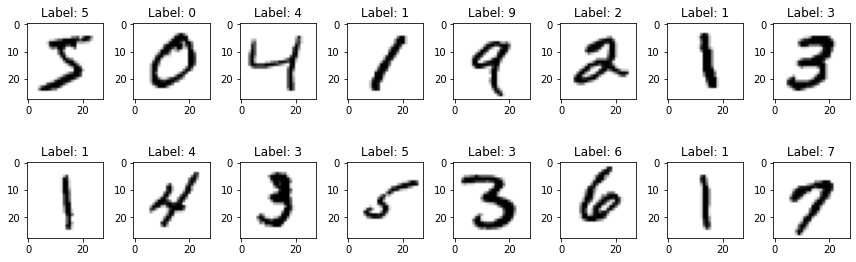

AFTER:



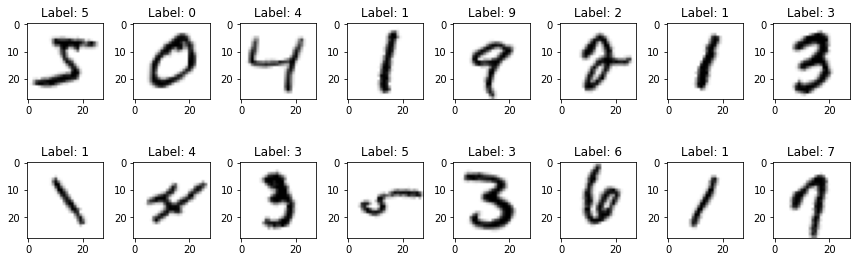

In [32]:
# fit the generator
datagen_rotate.fit(x_train.reshape(x_train.shape[0], 28, 28, 1))
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(x_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen_rotate.flow(x_train.reshape(x_train.shape[0], 28, 28, 1),y_train.reshape(y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

In [33]:
# Shifting 
datagen_shift = ImageDataGenerator(width_shift_range=0.25, height_shift_range=0.25)
datagen_shift.fit(x_subsets[0].reshape(x_subsets[0].shape[0], 28, 28, 1))

BEFORE:



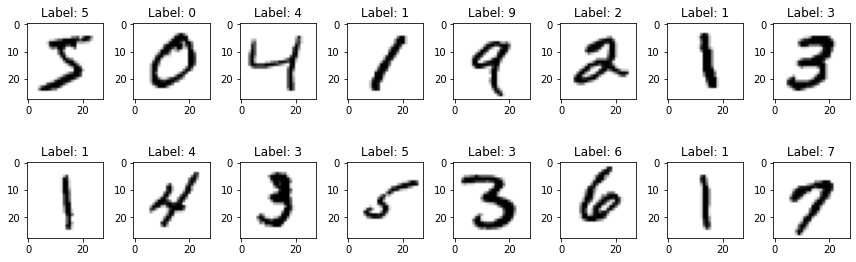

AFTER:



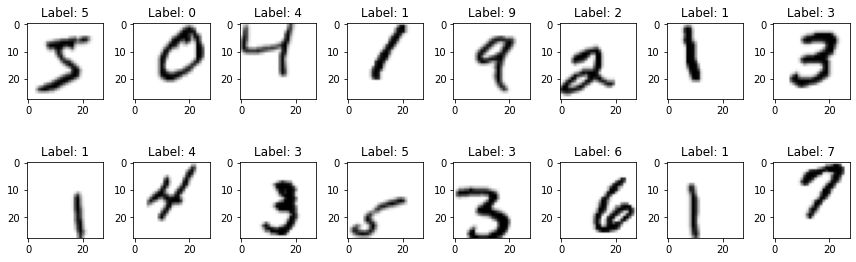

In [34]:
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(x_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen_shift.flow(x_train.reshape(x_train.shape[0], 28, 28, 1),y_train.reshape(y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

In [35]:
# Shear
shear_range_val=45
# create the class object
datagen_shear = ImageDataGenerator(shear_range=shear_range_val)
# fit the generator
datagen_shear.fit(x_subsets[0].reshape(x_subsets[0].shape[0], 28, 28, 1))

BEFORE:



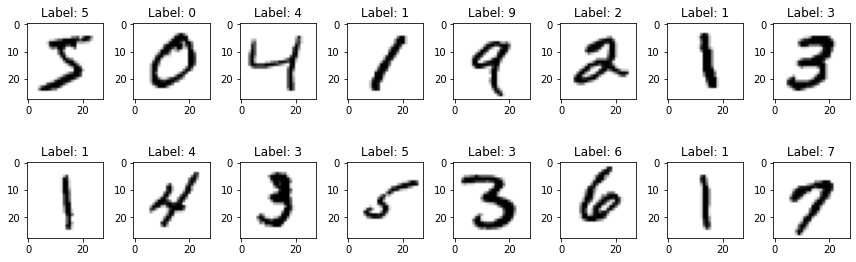

AFTER:



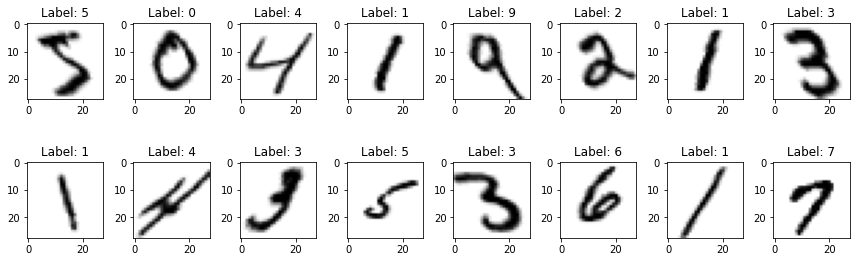

In [36]:
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(x_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen_shear.flow(x_train.reshape(x_train.shape[0], 28, 28, 1),y_train.reshape(y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

In [37]:
# Zoom
zoom_range_val=[0.5,1.5]
# create the class object
datagen_zoom = ImageDataGenerator(zoom_range=zoom_range_val)
# fit the generator
datagen_zoom.fit(x_train.reshape(x_train.shape[0], 28, 28, 1))

BEFORE:



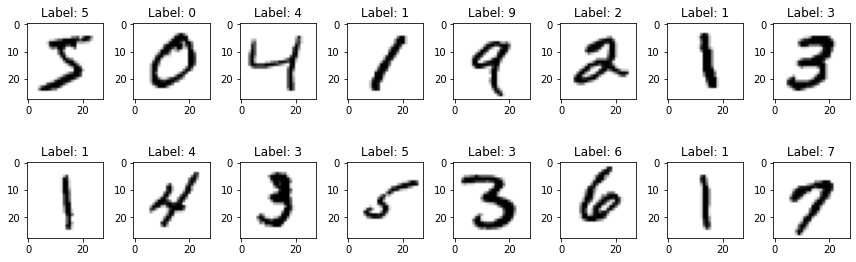

AFTER:



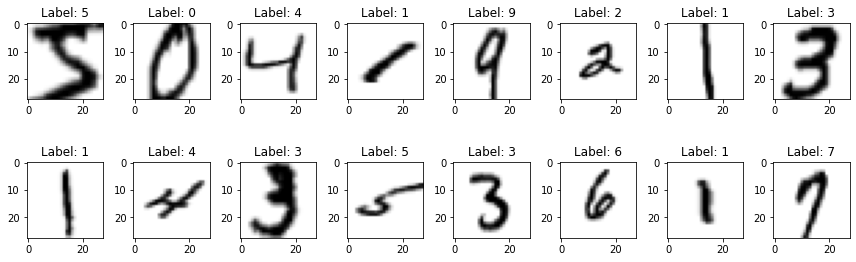

In [38]:
# define number of rows & columns
num_row = 2
num_col = 8
num= num_row*num_col
# plot before
print('BEFORE:\n')
# plot images
fig1, axes1 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for i in range(num):
     ax = axes1[i//num_col, i%num_col]
     ax.imshow(x_train[i], cmap='gray_r')
     ax.set_title('Label: {}'.format(y_train[i]))
plt.tight_layout()
plt.show()
# plot after
print('AFTER:\n')
fig2, axes2 = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
for X, Y in datagen_zoom.flow(x_train.reshape(x_train.shape[0], 28, 28, 1),y_train.reshape(y_train.shape[0], 1),batch_size=num,shuffle=False):
     for i in range(0, num):
          ax = axes2[i//num_col, i%num_col]
          ax.imshow(X[i].reshape(28,28), cmap='gray_r')
          ax.set_title('Label: {}'.format(int(Y[i])))
     break
plt.tight_layout()
plt.show()

####### PFE #######

In [ ]:
# TODO: find a way to add augmented data to (subsets of) the original data
def augment(method, x_subset, y_subset, batch_size):
    
    rotation_range_val = 30
    width_shift_range = 0.25
    height_shift_range = 0.25
    shear_range_val = 45
    zoom_range_val = [0.5, 1.5]
    
    methods = {
        "rotate": ImageDataGenerator(rotation_range=rotation_range_val),
        "shift": ImageDataGenerator(width_shift_range=width_shift_range, height_shift_range=height_shift_range),
        "shear": ImageDataGenerator(shear_range=shear_range_val),
        "zoom": ImageDataGenerator(zoom_range=zoom_range_val)
    }

    data_gen = methods[method]
    data_gen.fit(x_subset.reshape(x_subset.shape[0], 28, 28, 1))
    iterator = data_gen.flow(x_subset.reshape(x_subset.shape[0], 28, 28, 1), y_subset.reshape(y_subset.shape[0], 1), batch_size=batch_size, shuffle=False)
    
    return iterator

In [ ]:
run_experiment("MNIST", np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "kl", 10)
run_experiment("MNIST", np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "kolmogorov-smirnov", 10)
run_experiment("MNIST",np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "wd", 10)
run_experiment("MNIST",np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "gini", 10)

In [120]:
run_experiment("CIFAR10", np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "kl", 10)
run_experiment("CIFAR10", np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "kolmogorov-smirnov", 10)
run_experiment("CIFAR10",np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "wd", 10)
run_experiment("CIFAR10",np.arange(0.5, 100.5, 0.5).tolist(), "D:/", "hetero-dir", "gini", 10)

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


KeyboardInterrupt: 

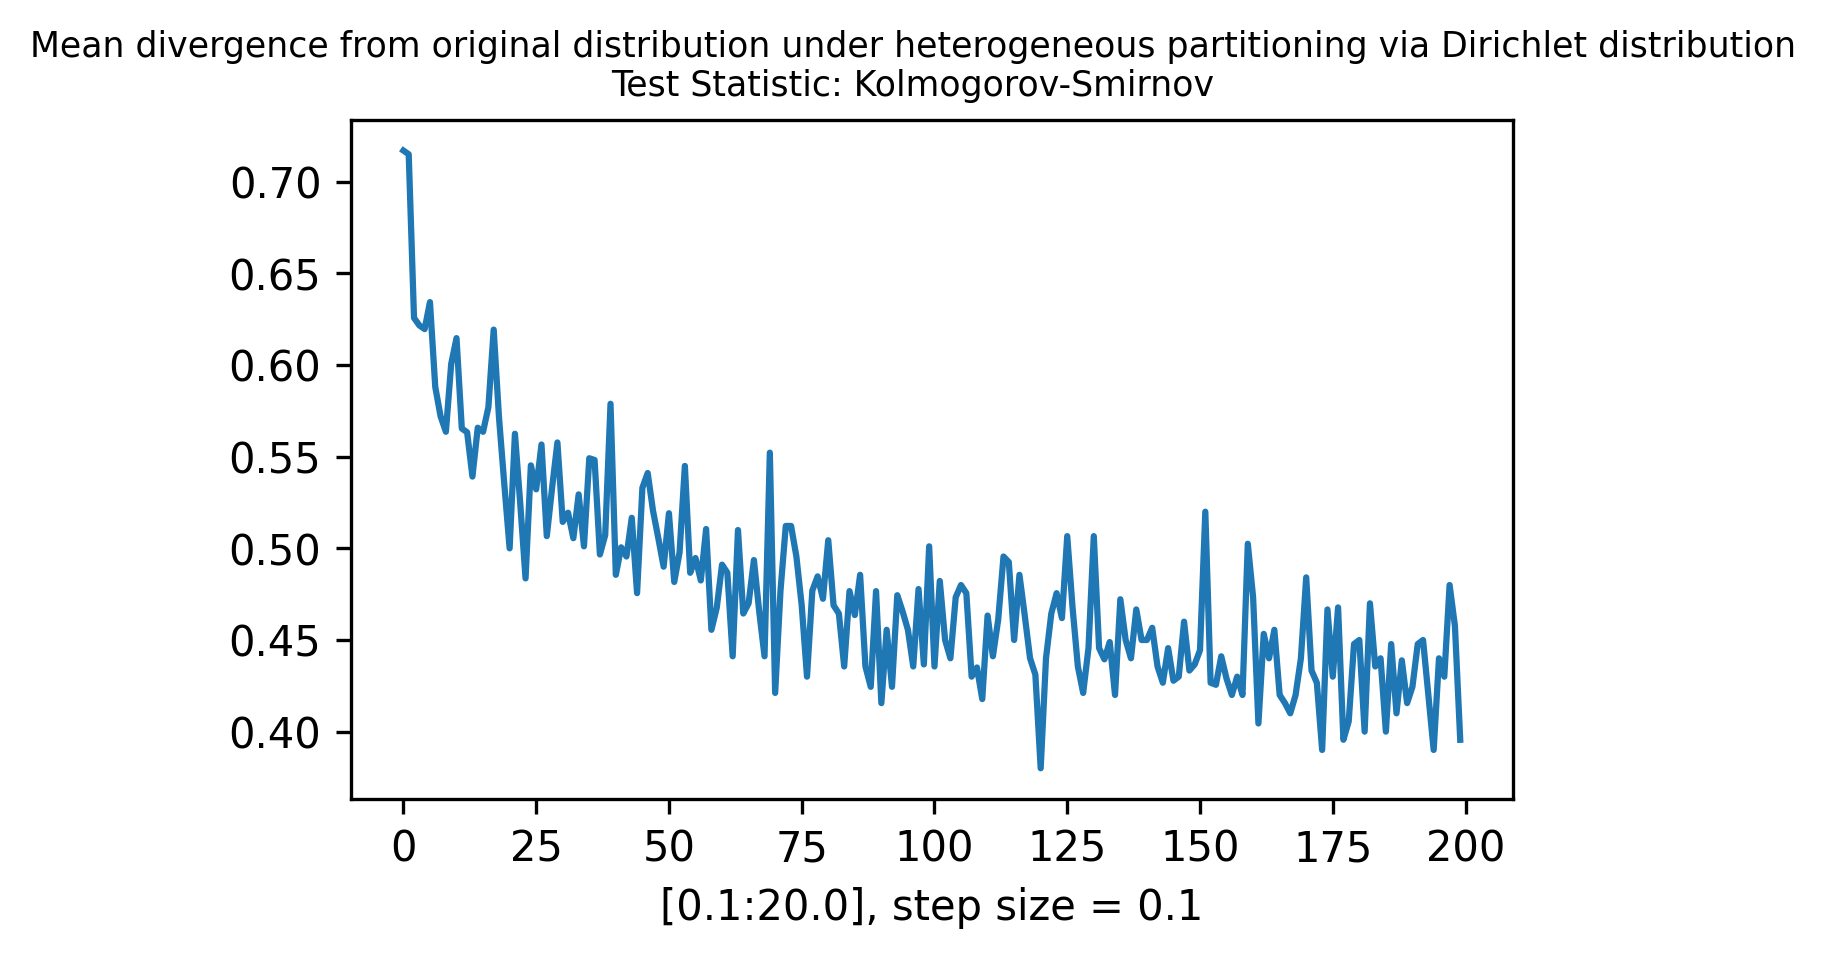

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


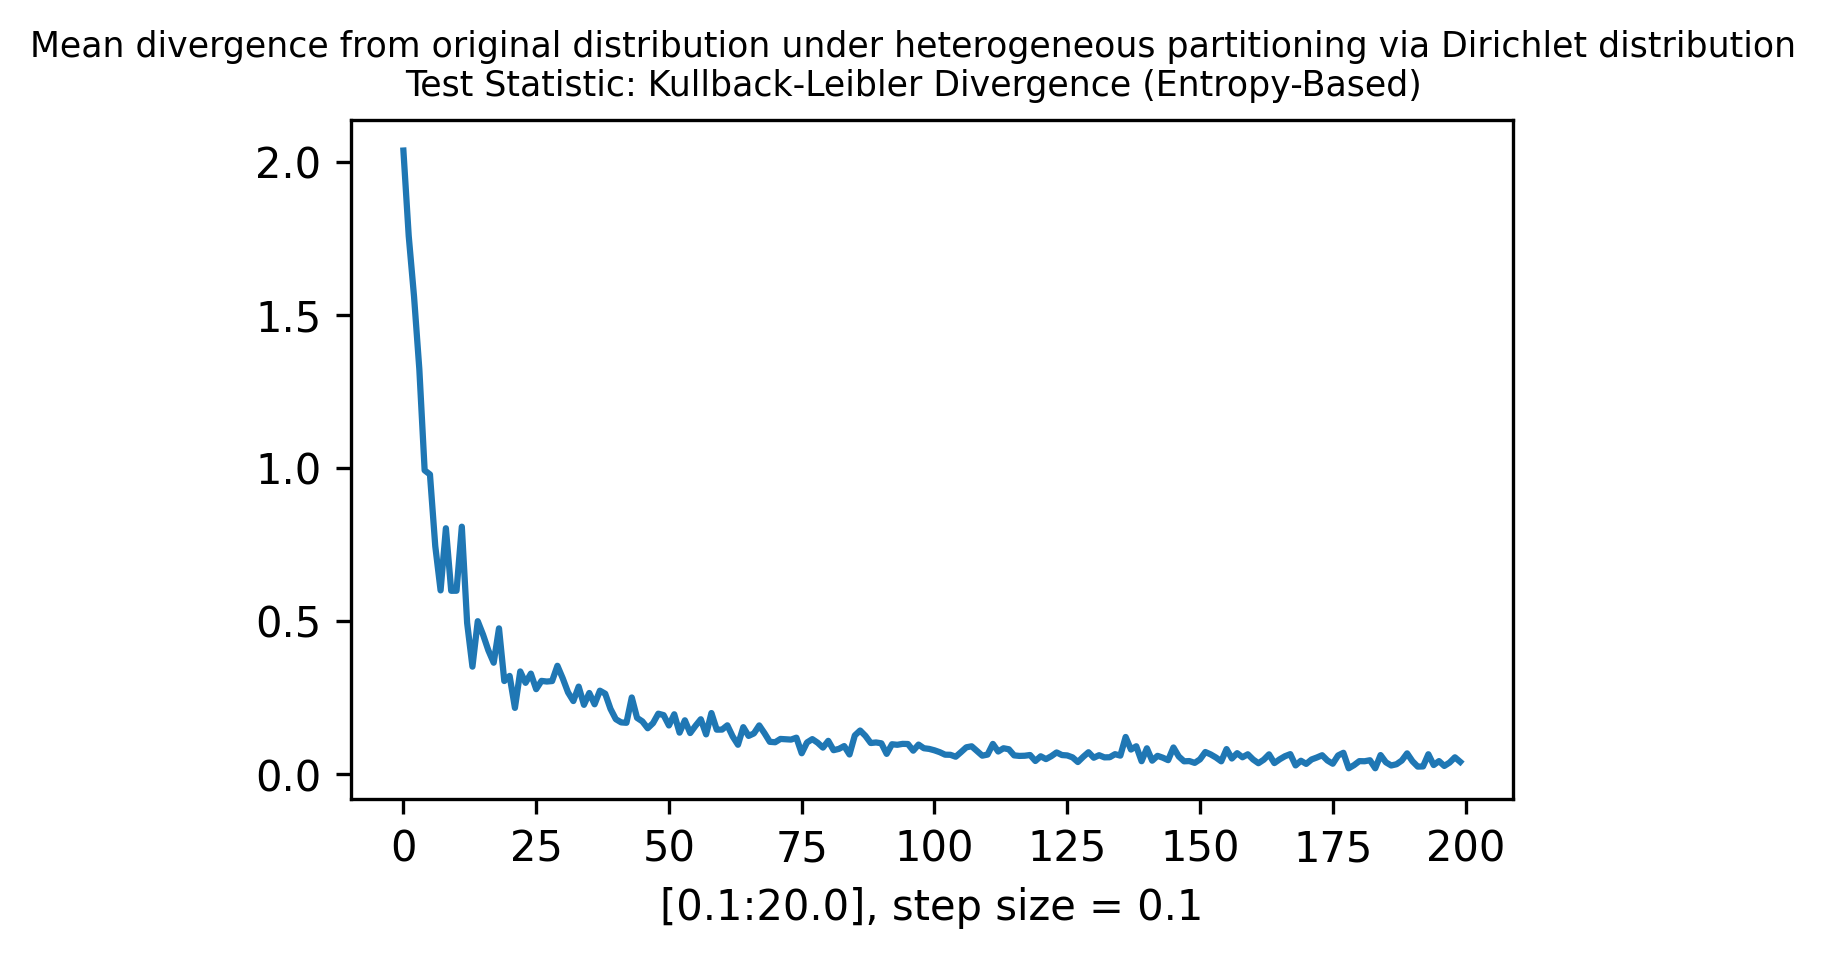

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


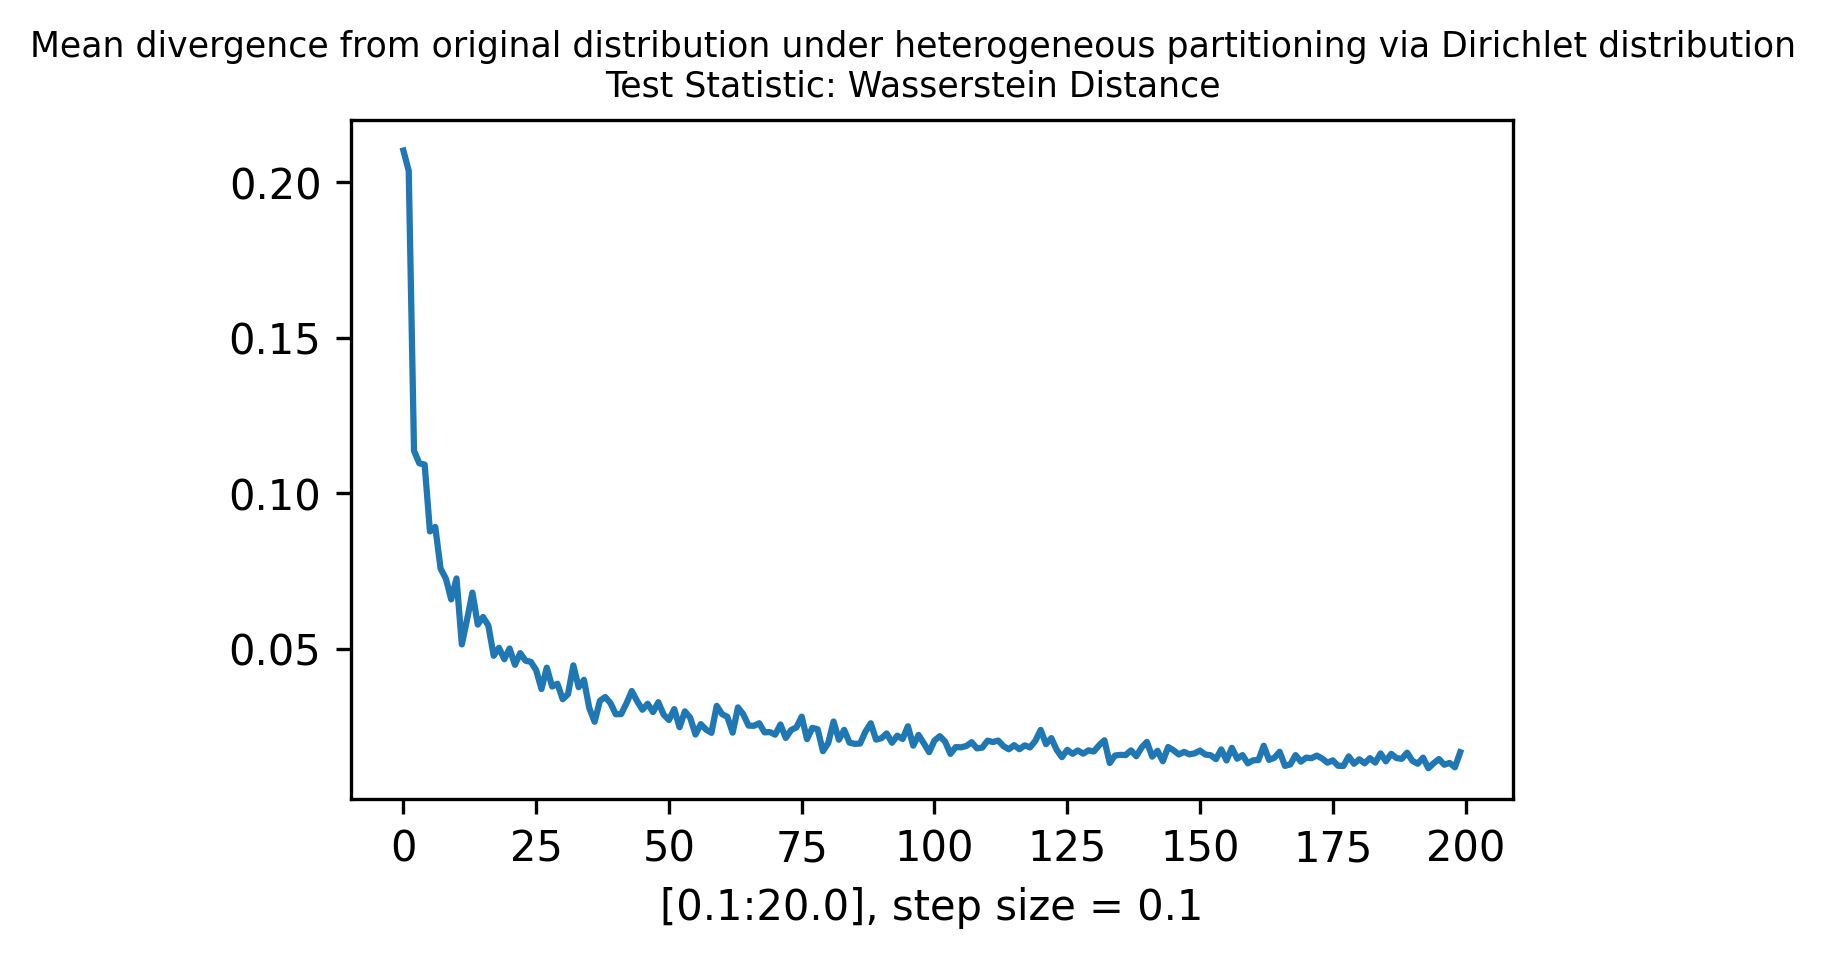

In [64]:
run_experiment(np.arange(0.1, 20.1, 0.1).tolist(), "D:/", "hetero-dir", "kolmogorov-smirnov", 10)
run_experiment(np.arange(0.1, 20.1, 0.1).tolist(), "D:/", "hetero-dir", "kl", 10)
run_experiment(np.arange(0.1, 20.1, 0.1).tolist(), "D:/", "hetero-dir", "wd", 10)

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


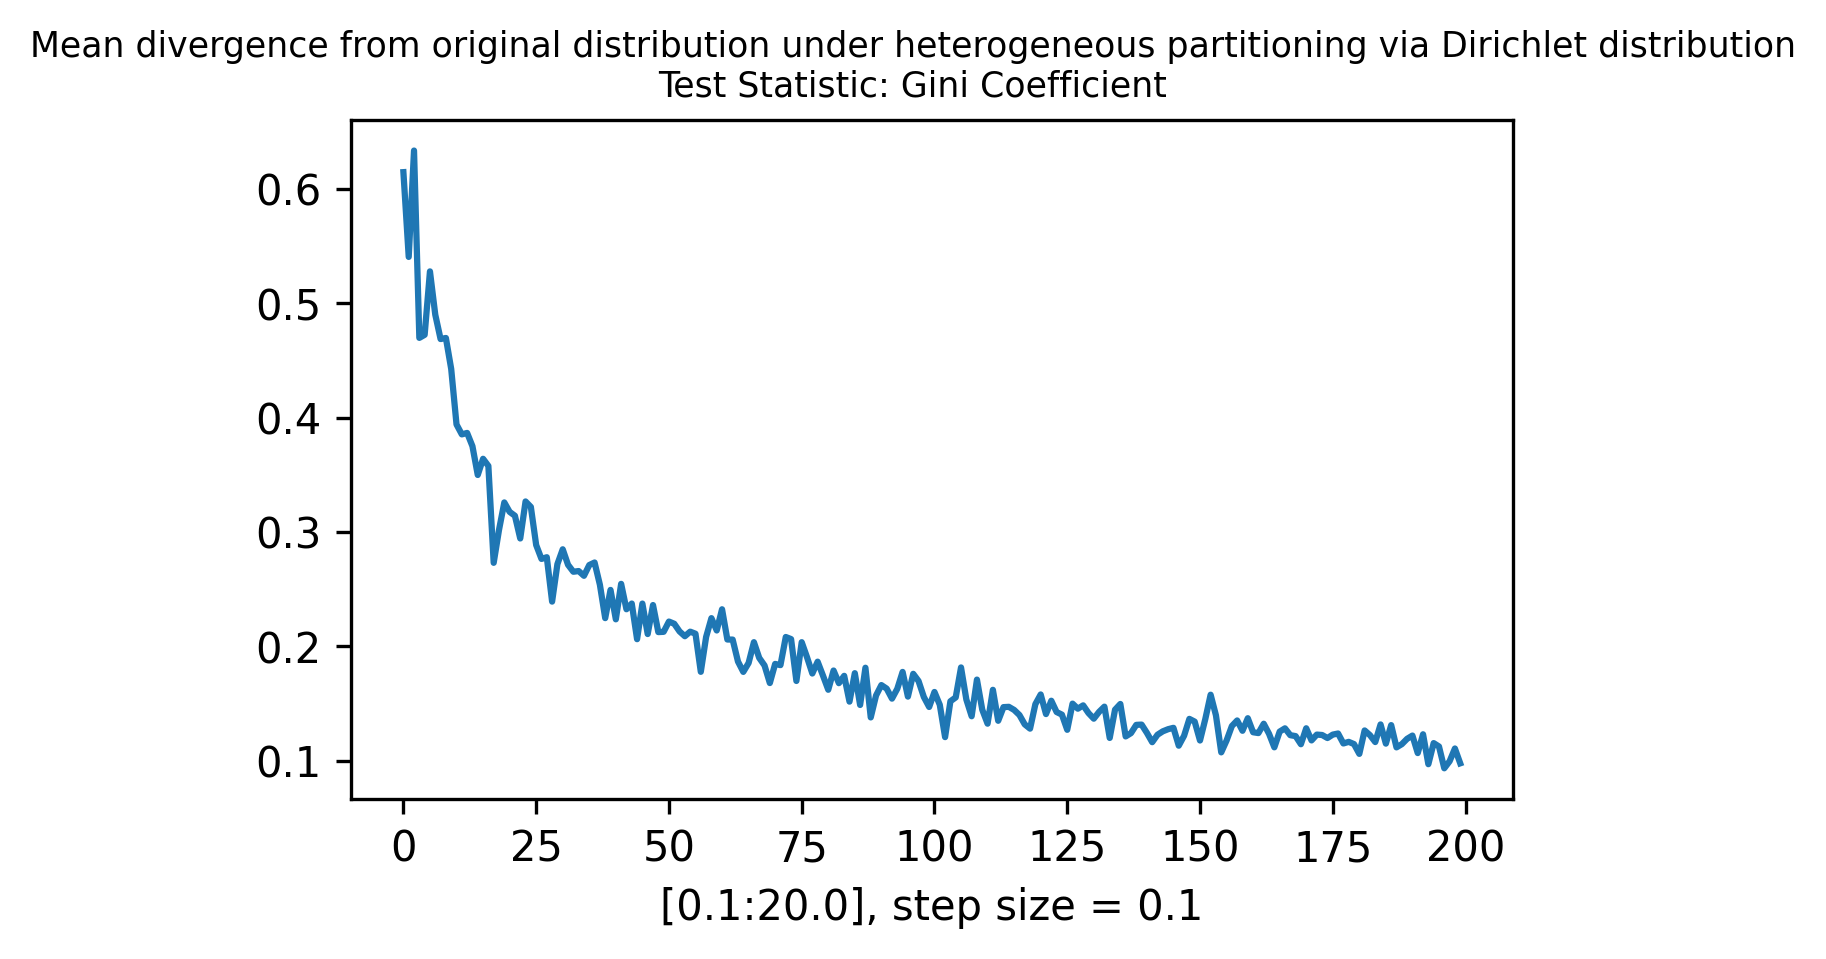

In [65]:
run_experiment(np.arange(0.1, 20.1, 0.1).tolist(), "D:/", "hetero-dir", "gini", 10)

In [ ]:
run_experiment(np.arange(0.1, 20.1, 0.1).tolist(), "D:/", "hetero-gaussian", "gini", 10)

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


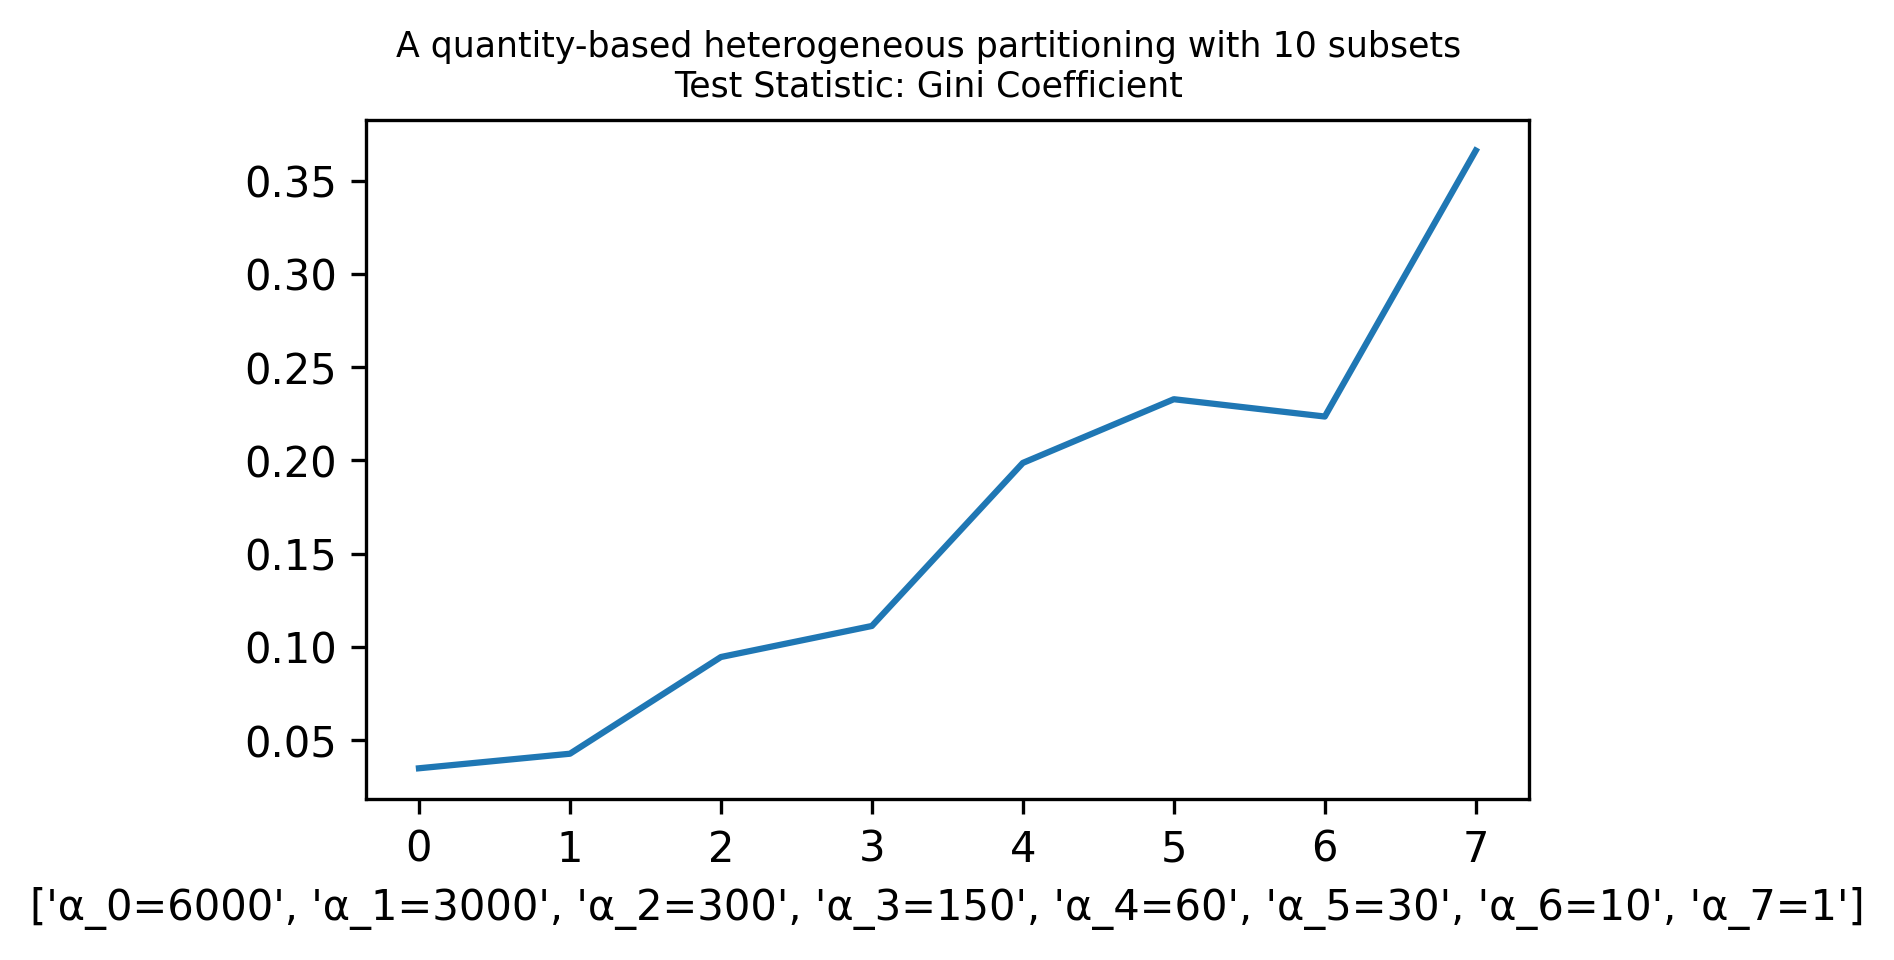

In [45]:
alpha_quant = [1, 10, 30, 60, 150, 300, 3000, 6000]
run_experiment([alpha_quant[len(alpha_quant)-j-1] for j in range(len(alpha_quant))], "D:/", "quant", "gini", 10)

In [ ]:
def getDivs(N):
    factors = {1}
    maxP  = int(N**0.5)
    p,inc = 2,1
    while p <= maxP:
        while N%p==0:
            factors.update([f*p for f in factors])
            N //= p
            maxP = int(N**0.5)
        p,inc = p+inc,2
    if N>1:
        factors.update([f*N for f in factors])
    return sorted(factors)  

Please run this 

C:\Users\AYBKE~1\AppData\Local\Temp/ipykernel_19640/461565894.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  minibatches = np.array(minibatches)
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


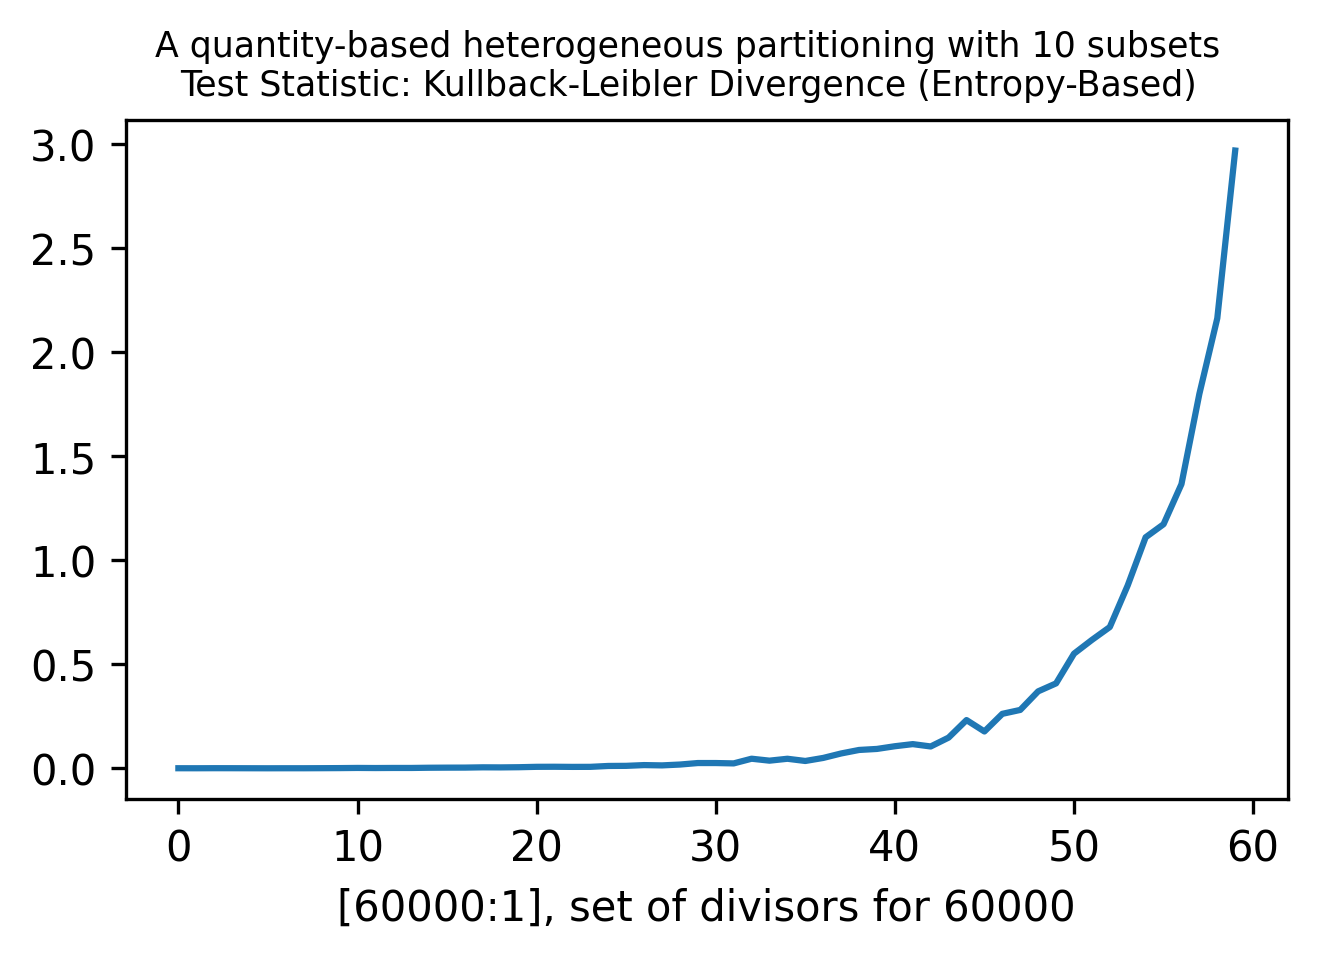

C:\Users\AYBKE~1\AppData\Local\Temp/ipykernel_19640/461565894.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  minibatches = np.array(minibatches)


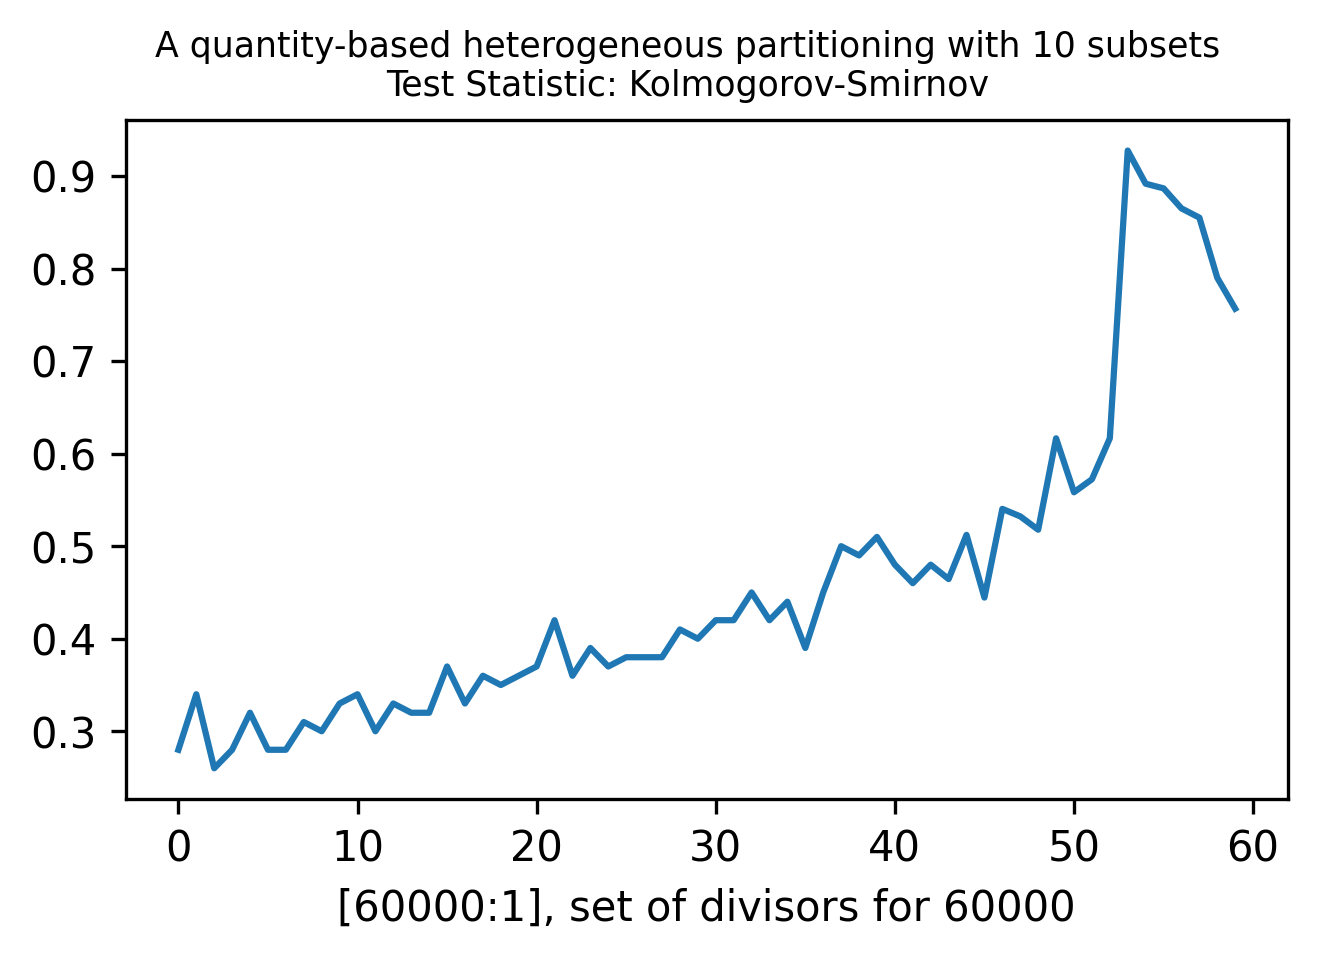

C:\Users\AYBKE~1\AppData\Local\Temp/ipykernel_19640/461565894.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  minibatches = np.array(minibatches)
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


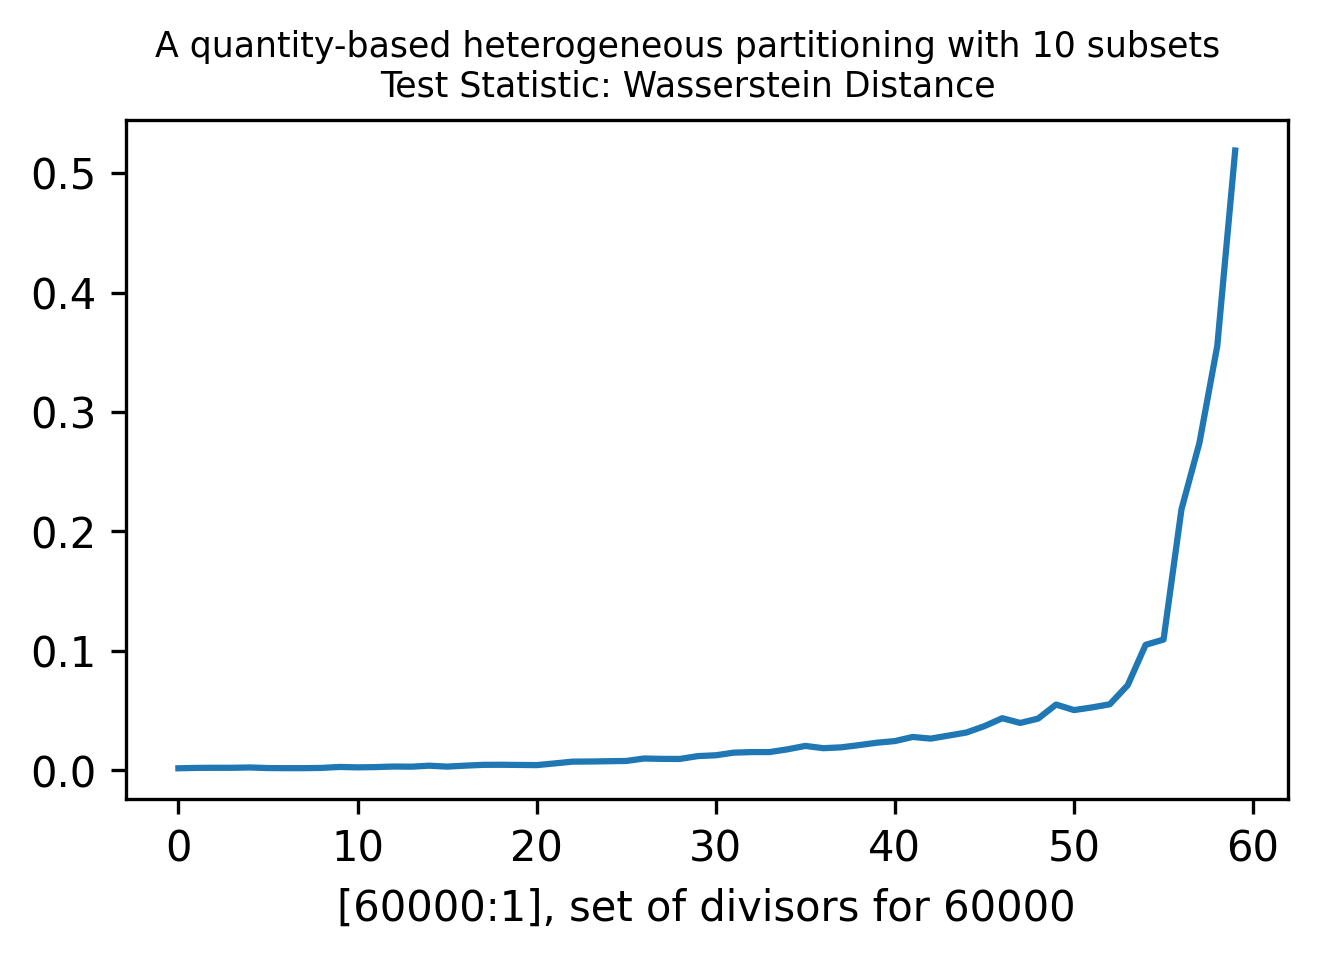

C:\Users\AYBKE~1\AppData\Local\Temp/ipykernel_19640/461565894.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  minibatches = np.array(minibatches)
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


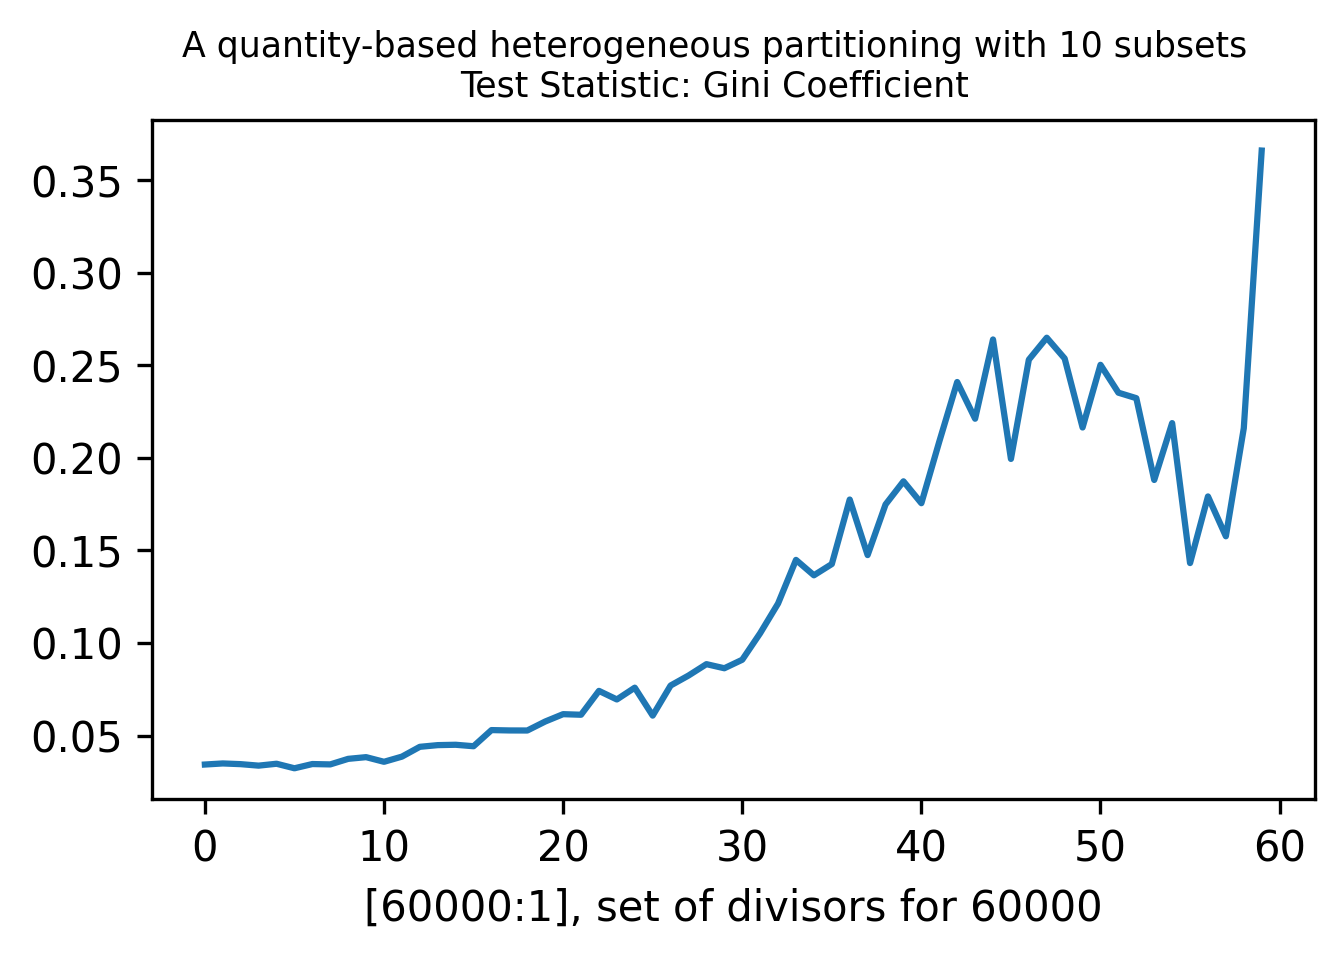

In [58]:
run_experiment("MNIST", getDivs(60000)[::-1], "D:/", "quant", "kl", 10)
run_experiment("MNIST",getDivs(60000)[::-1], "D:/", "quant", "kolmogorov-smirnov", 10)
run_experiment("MNIST",getDivs(60000)[::-1], "D:/", "quant", "wd", 10)
run_experiment("MNIST",getDivs(60000)[::-1], "D:/", "quant", "gini", 10)

C:\Users\AYBKE~1\AppData\Local\Temp/ipykernel_19640/461565894.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  minibatches = np.array(minibatches)
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


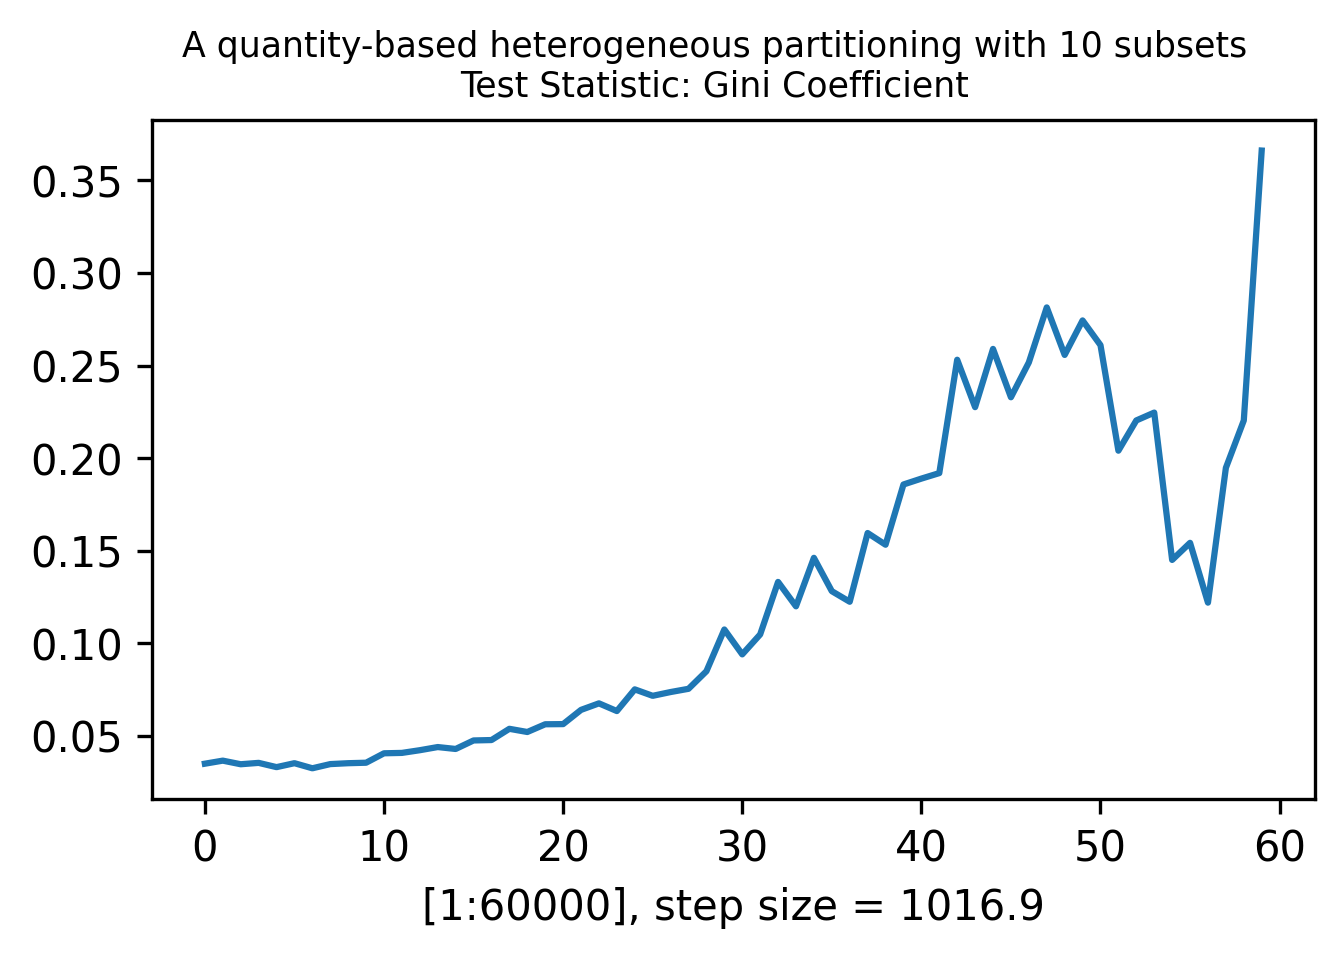

In [52]:
# alpha_quant = [60000, 20000, 6000, 2000, 900, 300, 90, 27, 9, 3, 1]
run_experiment(getDivs(60000)[::-1], "D:/", "quant", "gini", 10)

In [ ]:
run_experiment("CIFAR10", getDivs(50000)[::-1], "D:/", "quant", "kl", 10)
run_experiment("CIFAR10",getDivs(50000)[::-1], "D:/", "quant", "kolmogorov-smirnov", 10)
run_experiment("CIFAR10",getDivs(50000)[::-1], "D:/", "quant", "wd", 10)
run_experiment("CIFAR10",getDivs(50000)[::-1], "D:/", "quant", "gini", 10)